# Sistem Prediksi Penjualan UMKM Menggunakan Random Forest

Notebook ini berisi alur eksperimen terstruktur untuk prototype Proyek Utama Informatika.

## 1. Tujuan

Memprediksi `total_penjualan` harian UMKM umum menggunakan Random Forest Regression pada dataset dummy sintetis yang aman.

In [12]:
# !pip install pandas>=2.3
# !pip install numpy>=2.0
# !pip install scikit-learn>=1.7
# !pip install streamlit>=1.48
# !pip install joblib>=1.4
# !pip install matplotlib>=3.9
# !pip install seaborn>=0.13
# !pip install nbformat>=5.10
# !pip install python-docx>=1.1
# !pip install reportlab>=4.2


In [13]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 2. Load Dataset

In [14]:
DATA_PATH = Path('../data/dummy_penjualan_umkm.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])
df.head()

,tanggal,id_produk,nama_produk,kategori_produk,harga_satuan,stok_awal,stok_akhir,jumlah_terjual,total_penjualan,diskon_persen,promo_aktif,biaya_promosi,kanal_penjualan,hari_dalam_minggu,akhir_pekan,bulan,musim_ramadan_lebaran,cuaca,jumlah_pengunjung,rating_produk
0,2024-01-01,P001,Paket nasi lauk,makanan_minuman,17000,31,12,19,323000,0,0,0,online,Monday,0,1,0,hujan_ringan,70,4.6
1,2024-01-01,P002,Minuman kopi susu,makanan_minuman,15500,47,23,24,372000,0,0,0,online,Monday,0,1,0,hujan_ringan,70,4.3
2,2024-01-01,P003,Snack kemasan lokal,makanan_minuman,9000,46,7,39,351000,0,0,0,online,Monday,0,1,0,hujan_ringan,70,4.3
3,2024-01-01,P004,Kaos basic,fashion,70000,15,6,9,598500,5,1,31500,online,Monday,0,1,0,hujan_ringan,70,4.4
4,2024-01-01,P005,Hijab polos,fashion,41000,17,2,15,615000,0,0,0,offline,Monday,0,1,0,hujan_ringan,70,4.6


In [15]:
df.info()
df.describe(include='all').T.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 6564 entries, 0 to 6563
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tanggal                6564 non-null   datetime64[us]
 1   id_produk              6564 non-null   str           
 2   nama_produk            6564 non-null   str           
 3   kategori_produk        6564 non-null   str           
 4   harga_satuan           6564 non-null   int64         
 5   stok_awal              6564 non-null   int64         
 6   stok_akhir             6564 non-null   int64         
 7   jumlah_terjual         6564 non-null   int64         
 8   total_penjualan        6564 non-null   int64         
 9   diskon_persen          6564 non-null   int64         
 10  promo_aktif            6564 non-null   int64         
 11  biaya_promosi          6564 non-null   int64         
 12  kanal_penjualan        6564 non-null   str           
 13  hari_dalam_min

<class 'pandas.DataFrame'>
RangeIndex: 6564 entries, 0 to 6563
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tanggal                6564 non-null   datetime64[us]
 1   id_produk              6564 non-null   str           
 2   nama_produk            6564 non-null   str           
 3   kategori_produk        6564 non-null   str           
 4   harga_satuan           6564 non-null   int64         
 5   stok_awal              6564 non-null   int64         
 6   stok_akhir             6564 non-null   int64         
 7   jumlah_terjual         6564 non-null   int64         
 8   total_penjualan        6564 non-null   int64         
 9   diskon_persen          6564 non-null   int64         
 10  promo_aktif            6564 non-null   int64         
 11  biaya_promosi          6564 non-null   int64         
 12  kanal_penjualan        6564 non-null   str           
 13  hari_dalam_min

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tanggal,6564,NaN,NaN,NaN,2024-09-30 00:00:00,2024-01-01 00:00:00,2024-05-16 00:00:00,2024-09-30 00:00:00,2025-02-14 00:00:00,2025-06-30 00:00:00,NaN
id_produk,6564,12,P001,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nama_produk,6564,12,Paket nasi lauk,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kategori_produk,6564,5,makanan_minuman,1641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
harga_satuan,6564.0,NaN,NaN,NaN,39762.873248,8000.0,17500.0,33000.0,59625.0,107000.0,26236.734637
stok_awal,6564.0,NaN,NaN,NaN,39.846435,3.0,19.0,32.0,54.0,213.0,28.699516
stok_akhir,6564.0,NaN,NaN,NaN,13.972425,0.0,5.0,10.0,19.0,129.0,13.488309
jumlah_terjual,6564.0,NaN,NaN,NaN,25.87401,0.0,12.0,21.0,35.0,151.0,18.279847
total_penjualan,6564.0,NaN,NaN,NaN,684583.927483,0.0,462000.0,615000.0,837000.0,2843400.0,321602.952705
diskon_persen,6564.0,NaN,NaN,NaN,1.973644,0.0,0.0,0.0,0.0,20.0,4.382595


## 3. Validasi Data

Cek nilai kosong, target negatif, dan rentang tanggal.

In [16]:
print('Missing values:')
print(df.isna().sum())
print('Target negatif:', (df['total_penjualan'] < 0).sum())
print(df['tanggal'].min(), df['tanggal'].max())

Missing values:
tanggal                  0
id_produk                0
nama_produk              0
kategori_produk          0
harga_satuan             0
stok_awal                0
stok_akhir               0
jumlah_terjual           0
total_penjualan          0
diskon_persen            0
promo_aktif              0
biaya_promosi            0
kanal_penjualan          0
hari_dalam_minggu        0
akhir_pekan              0
bulan                    0
musim_ramadan_lebaran    0
cuaca                    0
jumlah_pengunjung        0
rating_produk            0
dtype: int64
Target negatif: 0
2024-01-01 00:00:00 2025-06-30 00:00:00


## 4. Exploratory Data Analysis

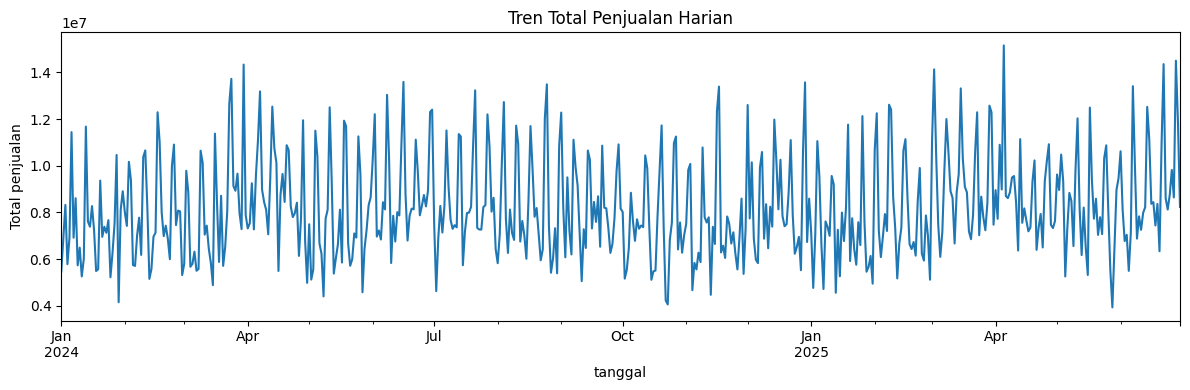

In [17]:
daily_sales = df.groupby('tanggal')['total_penjualan'].sum()
plt.figure(figsize=(12, 4))
daily_sales.plot()
plt.title('Tren Total Penjualan Harian')
plt.ylabel('Total penjualan')
plt.tight_layout()
plt.show()

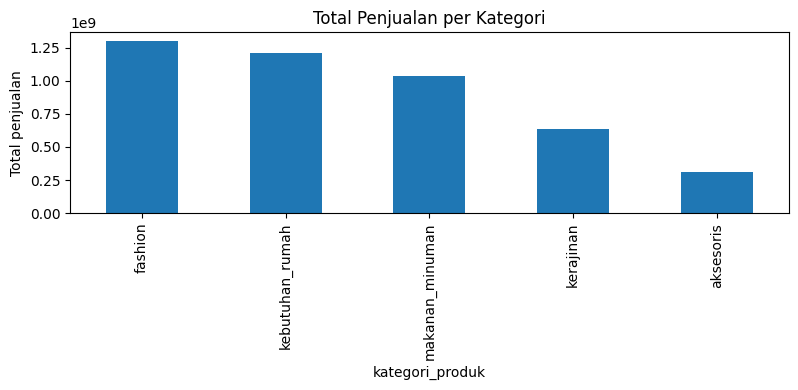

In [18]:
category_sales = df.groupby('kategori_produk')['total_penjualan'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
category_sales.plot(kind='bar')
plt.title('Total Penjualan per Kategori')
plt.ylabel('Total penjualan')
plt.tight_layout()
plt.show()

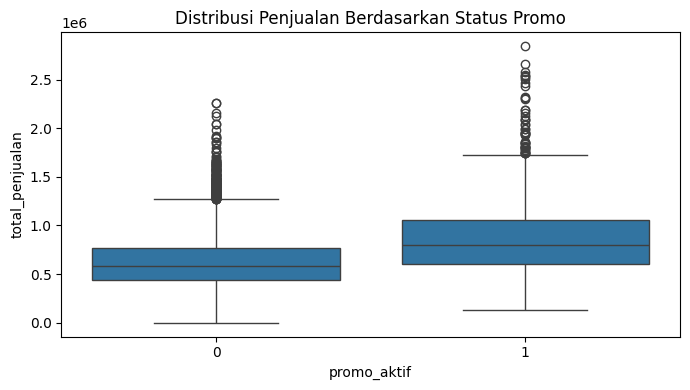

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='promo_aktif', y='total_penjualan')
plt.title('Distribusi Penjualan Berdasarkan Status Promo')
plt.tight_layout()
plt.show()

## 5. Pemodelan

Training dilakukan melalui script `src/train_model.py`. Fitur pasca transaksi seperti `jumlah_terjual`, `stok_akhir`, dan `biaya_promosi` tidak dipakai agar tidak terjadi data leakage.

In [20]:
import sys
sys.path.append('..')
from src.train_model import FEATURES, TARGET, build_pipeline, evaluate, load_dataset, split_by_time

df = load_dataset(Path('../data/dummy_penjualan_umkm.csv'))
train_df, test_df = split_by_time(df)
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

model = build_pipeline()
model.fit(X_train, y_train)
pred = model.predict(X_test)
evaluate(y_test, pred)

{'mae': 134714.57067205198,
 'rmse': 186598.54103915638,
 'r2': 0.6683978610021679,
 'mape': 20.78833526168277}

## 6. Load Artefak Training

In [21]:
MODEL_PATH = Path('../models/random_forest_penjualan_umkm.joblib')
METRICS_PATH = Path('../reports/model_metrics.json')
IMPORTANCE_PATH = Path('../reports/feature_importance.csv')

bundle = joblib.load(MODEL_PATH)
metrics = json.loads(METRICS_PATH.read_text())
importance = pd.read_csv(IMPORTANCE_PATH)
metrics

{'mae': 135657.2409079088,
 'rmse': 186176.87342560687,
 'r2': 0.6698948490865074,
 'mape': 20.708396842639377,
 'cv_mae_mean': 137137.84189518317,
 'cv_mae_std': 9918.845568834126,
 'train_rows': 5244,
 'test_rows': 1320,
 'train_start': '2024-01-01',
 'train_end': '2025-03-12',
 'test_start': '2025-03-13',
 'test_end': '2025-06-30'}

In [22]:
importance.head(15)

,feature,importance
0,nama_produk_Beras 5 kg,0.167611
1,stok_awal,0.148713
2,jumlah_pengunjung,0.132406
3,akhir_pekan,0.123508
4,harga_satuan,0.094571
5,kategori_produk_fashion,0.048454
6,day_of_month,0.031619
7,week_of_year,0.027440
8,diskon_persen,0.024822
9,rating_produk,0.022140


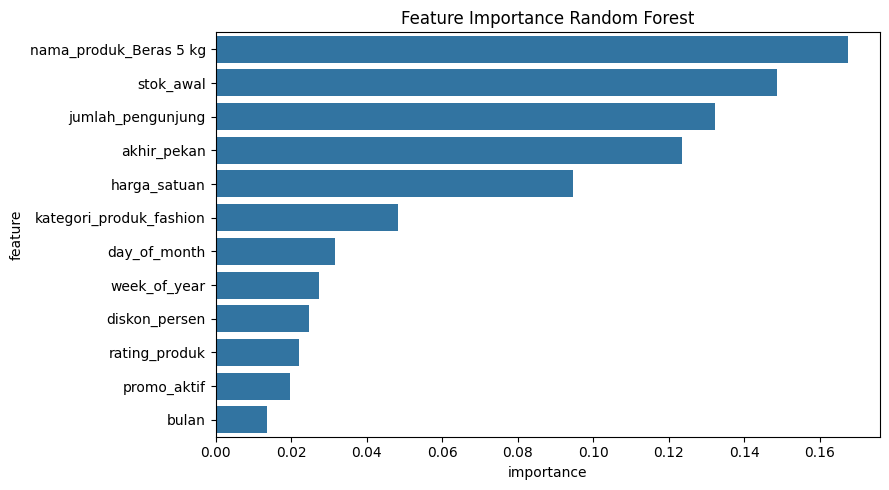

In [23]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance.head(12), y='feature', x='importance')
plt.title('Feature Importance Random Forest')
plt.tight_layout()
plt.show()

## 7. Interpretasi

Metrik menunjukkan performa pada dataset dummy. Kesimpulan tidak boleh digeneralisasi ke UMKM nyata sebelum validasi memakai data transaksi asli.

## 8. Saran Lanjutan

Gunakan data POS asli, buat validasi data, lakukan perbandingan model, dan monitoring error setelah sistem dipakai.